In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
ton_iot_dataset = pd.read_csv("train_test_network.csv")
testbed_dataset = pd.read_csv("dataset_training_iot.csv")

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Testbed loaded   : ({testbed_dataset.shape}")

TON-IoT loaded   : (211043, 44)
Testbed loaded   : ((36100, 47)


In [3]:
print(ton_iot_dataset['label'].value_counts())
print(ton_iot_dataset['type'].value_counts())

label
1    161043
0     50000
Name: count, dtype: int64
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [4]:
print(testbed_dataset['label'].value_counts())
print(testbed_dataset['type'].value_counts())

label
1    30986
0     5114
Name: count, dtype: int64
type
injection    5769
normal       5114
ddos         5094
mitm         5086
password     5037
dos          5000
scanning     5000
Name: count, dtype: int64


In [5]:
ton_iot_dataset.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [6]:
testbed_dataset.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,mqtt_topic_len,mqtt_payload_len,mqtt_operation,label,type
0,172.18.0.4,41310,172.18.0.2,1883,tcp,mqtt,0.000326,99,4,SF,...,-,-,-,-,F,30.0,0,2.0,0,normal
1,172.18.0.4,34806,172.18.0.2,1883,tcp,mqtt,0.000443,99,4,SF,...,-,-,-,-,F,30.0,0,2.0,1,mitm
2,172.18.0.2,8377,172.18.0.3,1883,tcp,0,0.000008,0,0,RSTO,...,-,-,-,-,F,0.0,0,0.0,1,dos
3,172.18.0.3,46235,172.18.0.2,4279,tcp,0,0.000002,0,0,REJ,...,-,-,-,-,F,0.0,0,0.0,1,scanning
4,172.18.0.3,46235,172.18.0.2,2004,tcp,0,0.000002,0,0,REJ,...,-,-,-,-,F,0.0,0,0.0,1,scanning


In [7]:
ton_iot_dataset.replace("-", "n/a", inplace=True)
testbed_dataset.replace("-", "n/a", inplace=True)

print(f"TON-IoT loaded   : {ton_iot_dataset.shape}")
print(f"Testbed loaded   : ({testbed_dataset.shape}")

TON-IoT loaded   : (211043, 44)
Testbed loaded   : ((36100, 47)


In [8]:
drop_always  = ["src_ip", "dst_ip", "src_port", "dst_port", "type"]

ton_iot_dataset = ton_iot_dataset.drop(columns=[c for c in drop_always if c in ton_iot_dataset.columns])
testbed_dataset = testbed_dataset.drop(columns=[c for c in drop_always if c in testbed_dataset.columns])

In [9]:
ton_iot_dataset.head()

,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,tcp,n/a,290.371539,101568,2592,OTH,0,108,108064,31,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
1,tcp,n/a,0.000102,0,0,REJ,0,1,52,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
2,tcp,n/a,0.000148,0,0,REJ,0,1,52,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
3,tcp,n/a,0.000113,0,0,REJ,0,1,48,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1
4,tcp,n/a,0.000130,0,0,REJ,0,1,52,1,...,0,0,0,n/a,n/a,n/a,n/a,n/a,n/a,1


In [10]:
testbed_dataset.head()

,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,...,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,mqtt_topic_len,mqtt_payload_len,mqtt_operation,label
0,tcp,mqtt,0.000326,99,4,SF,0,7,471,5,...,n/a,n/a,n/a,n/a,n/a,F,30.0,0,2.0,0
1,tcp,mqtt,0.000443,99,4,SF,0,7,471,5,...,n/a,n/a,n/a,n/a,n/a,F,30.0,0,2.0,1
2,tcp,0,0.000008,0,0,RSTO,0,2,80,1,...,n/a,n/a,n/a,n/a,n/a,F,0.0,0,0.0,1
3,tcp,0,0.000002,0,0,REJ,0,1,44,1,...,n/a,n/a,n/a,n/a,n/a,F,0.0,0,0.0,1
4,tcp,0,0.000002,0,0,REJ,0,1,44,1,...,n/a,n/a,n/a,n/a,n/a,F,0.0,0,0.0,1


In [11]:
mqtt_cols = ["mqtt_topic_len", "mqtt_payload_len", "mqtt_operation"]

for col in mqtt_cols:
    if col in testbed_dataset.columns and col not in ton_iot_dataset.columns:
        ton_iot_dataset[col] = "n/a"
        print(f"Added '{col}' to TON-IoT with fill value n/a")

assert set(ton_iot_dataset.columns) == set(testbed_dataset.columns), \
    "Column mismatch after alignment — check for unexpected extra columns"
print(f"\nColumn alignment confirmed — both datasets have {len(ton_iot_dataset.columns)} columns")

Added 'mqtt_topic_len' to TON-IoT with fill value n/a
Added 'mqtt_payload_len' to TON-IoT with fill value n/a
Added 'mqtt_operation' to TON-IoT with fill value n/a

Column alignment confirmed — both datasets have 42 columns


In [12]:
one_hot_columns = ["proto", "service", "conn_state",
                   "dns_AA", "dns_RD", "dns_RA", "dns_rejected",
                   "ssl_resumed", "ssl_established",
                   "http_trans_depth", "http_method", "http_version",
                   "weird_addl", "weird_notice", 
                   ]

binary_columns = ["dns_query",
                  "ssl_version", "ssl_cipher", "ssl_subject", "ssl_issuer",
                  "http_uri", "http_user_agent", "http_orig_mime_types", "http_resp_mime_types",
                  "weird_name", 
                  ]

for col in one_hot_columns + binary_columns:
    ton_iot_dataset[col] = ton_iot_dataset[col].astype('category')
    testbed_dataset[col] = testbed_dataset[col].astype('category')

In [13]:
from sklearn.preprocessing import  LabelEncoder

categorical_columns = one_hot_columns + binary_columns

combined_for_encoding = pd.concat([ton_iot_dataset, testbed_dataset], ignore_index=True)

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    combined_for_encoding[col] = le.fit_transform(combined_for_encoding[col].astype(str))
    encoders[col] = le

ton_enc = combined_for_encoding.iloc[:len(ton_iot_dataset)].reset_index(drop=True)
testbed_enc = combined_for_encoding.iloc[len(ton_iot_dataset):].reset_index(drop=True)

print(f"Categorical columns encoded : {len(categorical_columns)}")

for col in ton_enc.columns:
    if col == "label":
        continue
    ton_enc[col] = pd.to_numeric(ton_enc[col], errors="coerce").fillna(0).astype(float)
    testbed_enc[col]  = pd.to_numeric(testbed_enc[col],  errors="coerce").fillna(0).astype(float)

Categorical columns encoded : 24


In [14]:
X_testbed = testbed_enc.drop(columns=["label"])
y_testbed = testbed_enc["label"]

testbed_train, testbed_inference = train_test_split(
    testbed_enc,
    test_size=0.25,
    random_state=42,
    stratify=y_testbed
)

print(f"Testbed train portion : {testbed_train.shape}")
print(f"Testbed holdout       : {testbed_inference.shape}")
print(f"  Holdout benign      : {(testbed_inference['label'] == 0).sum()}")
print(f"  Holdout attack      : {(testbed_inference['label'] == 1).sum()}")
print(f"  Holdout attack ratio: {testbed_inference['label'].mean():.2%}")

Testbed train portion : (27075, 42)
Testbed holdout       : (9025, 42)
  Holdout benign      : 1279
  Holdout attack      : 7746
  Holdout attack ratio: 85.83%


In [15]:
combined_train = pd.concat([ton_enc, testbed_train], ignore_index=True).dropna()

X = combined_train.drop(columns=["label"])
y = combined_train["label"]

X_inference = testbed_inference.drop(columns=["label"])
y_inference = testbed_inference["label"].reset_index(drop=True)

print(f"Combined training set : {X.shape}")
print(f"  Benign samples      : {(y == 0).sum()}")
print(f"  Attack samples      : {(y == 1).sum()}")
print(f"  Attack ratio        : {y.mean():.2%}")

Combined training set : (238118, 41)
  Benign samples      : 53835
  Attack samples      : 184283
  Attack ratio        : 77.39%


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")

Training samples   : 190494
Validation samples : 47624


In [17]:
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
spw = neg / pos
print(f"scale_pos_weight = {spw:.4f}  (neg={neg}, pos={pos})")

def objective_xgb(trial):
    param = {
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth'         : trial.suggest_int('max_depth',5, 20),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_float('min_child_weight', 0.5, 2.0),
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 300),
        'max_leaves'        : trial.suggest_int('max_leaves', 1, 9),
        'objective'         : 'binary:logistic',
        'eval_metric'       : 'logloss',
        "scale_pos_weight"  : spw,
        'device'            : 'cuda',
        'tree_method'       : 'hist',
        'random_state'      : 42,
        "n_jobs"            : -1,
    }
    model = XGBClassifier(**param)
    model.fit(X_train, y_train)
    accuracy = model.score(X_val, y_val)
    return accuracy

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42)
)
study.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(f"\nBest Accuracy (CV) : {study.best_value:.4f}")
print(f"Best parameters   :")
for k, v in study.best_params.items():
    print(f"  {k:<22} : {v}")

[I 2026-03-15 20:54:30,613] A new study created in memory with name: no-name-3adc8e51-3a4d-466a-a861-c0f5cd3f136a


scale_pos_weight = 0.2921  (neg=43068, pos=147426)


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Francis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:774: UserWarning: [20:54:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[I 2026-03-15 20:54:31,563] Trial 0 finished with value: 0.9488913153032085 and parameters: {'learning_rate': 0.11861663446573512, 'max_depth': 20, 'subsample': 0.892797576724562, 'min_child_weight': 1.397987726295555, 'n_estimators': 131, 'max_leaves': 2}. Best is trial 0 with value: 0.9488913153032085.
[I 2026-03-15 20:54:32,427] Trial 1 finished with value: 0.9624769024021502 and parameters: {'learning_rate': 0.026844247528777843, 'max_depth': 18, 'subsample': 0.8404460046972835, 'min_child_weight': 1.5621088666940683, 'n_estimators': 104, 'max_leaves': 9}. Best is trial 1 with value: 0.9624769024021502.
[I 2026-03-15 20:54:33,469] Trial 2 finished with value: 0.9701411053250462 and parameters: {'learning_rate': 0.2514083658321223, 'max_depth': 8, 'subsample': 0.6727299868828402, 'min_child_weight': 0.7751067647801507, 'n_estimators': 161, 'max_leaves': 5}. Best is trial 2 with value: 0.9701411053250462.
[I 2026-03-15 20:54:34,323] Trial 3 finished with value: 0.9674743826642029 and

In [18]:
best_params = study.best_params
best_params.update({
    "scale_pos_weight" : spw,
    "eval_metric"      : "logloss",
    "random_state"     : 42,
    "n_jobs"           : -1,
})

model = XGBClassifier(**best_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

y_val_pred  = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

[0]	validation_0-logloss:0.50385
[50]	validation_0-logloss:0.06394
[100]	validation_0-logloss:0.05299
[150]	validation_0-logloss:0.04726
[200]	validation_0-logloss:0.04398
[250]	validation_0-logloss:0.04187
[274]	validation_0-logloss:0.04115


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("VALIDATION SCORES")
print("Accuracy: ", accuracy_score(y_val, y_val_pred))
print("Precision: ", precision_score(y_val, y_val_pred))
print("Recall: ", recall_score(y_val, y_val_pred))
print("F1 Score: ", f1_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("Classification Report:\n", classification_report(y_val, y_val_pred))

VALIDATION SCORES
Accuracy:  0.9813539391903242
Precision:  0.9957002287698795
Recall:  0.9801394579048756
F1 Score:  0.98785856873308
Confusion Matrix:
 [[10611   156]
 [  732 36125]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96     10767
           1       1.00      0.98      0.99     36857

    accuracy                           0.98     47624
   macro avg       0.97      0.98      0.97     47624
weighted avg       0.98      0.98      0.98     47624



In [20]:
y_inference_pred  = model.predict(X_inference)
y_inference_proba = model.predict_proba(X_inference)[:, 1]

print("INFERENCE SCORES")
print("Accuracy: ", accuracy_score(y_inference, y_inference_pred))
print("Precision: ", precision_score(y_inference, y_inference_pred))
print("Recall: ", recall_score(y_inference, y_inference_pred))
print("F1 Score: ", f1_score(y_inference, y_inference_pred))
print("Confusion Matrix:\n", confusion_matrix(y_inference, y_inference_pred))
print("Classification Report:\n", classification_report(y_inference, y_inference_pred))

INFERENCE SCORES
Accuracy:  0.8446537396121884
Precision:  0.9716027356526911
Recall:  0.8436612445132972
F1 Score:  0.9031232725262576
Confusion Matrix:
 [[1088  191]
 [1211 6535]]
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.85      0.61      1279
           1       0.97      0.84      0.90      7746

    accuracy                           0.84      9025
   macro avg       0.72      0.85      0.76      9025
weighted avg       0.90      0.84      0.86      9025



Feature importance plot saved to feature_importance.png


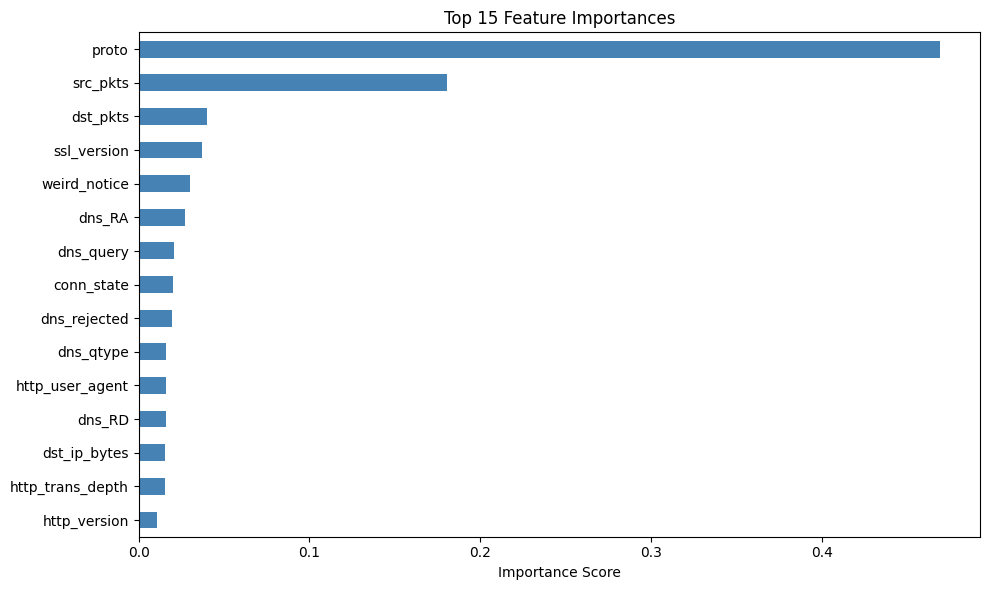

In [21]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)
 
plt.figure(figsize=(10, 6))
top_features.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
print("Feature importance plot saved to feature_importance.png")

In [22]:
import json
import joblib
 
joblib.dump(model,    "xgb_retrained.pkl")
print("Saved: xgb_retrained.pkl")
joblib.dump(encoders, "encoders_retrained.pkl")
print("Saved: encoders_retrained.pkl")
testbed_inference.to_csv("testbed_inference.csv", index=False)
print("Saved: testbed_inference.csv")

with open("best_params.json", "w") as f:
    json.dump(study.best_params, f, indent=2)
print("Saved: best_params.json")

Saved: xgb_retrained.pkl
Saved: encoders_retrained.pkl
Saved: testbed_inference.csv
Saved: best_params.json
